# Model Evaluation and Fairness Analysis
## Week 5 — Evaluating All Three Models
This notebook provides comprehensive evaluation of the trained models including:
- Standard metrics: accuracy, precision, recall, F1, ROC-AUC
- Confusion matrix visualization
- Calibration curve
- Fairness analysis sliced by ICD chapter, specialty, and age group
- Manual review of top 20 anomalies
- Model selection rationale

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_score, recall_score, f1_score
)
from sklearn.calibration import calibration_curve

os.chdir('/Users/darshanbalaji/Documents/healthcare-claims-ai/healthcare-claims-ai')

X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()

lr = joblib.load('models/denial_predictor_lr.pkl')
rf = joblib.load('models/denial_predictor_rf.pkl')

y_prob_lr = lr.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

y_pred_lr = (y_prob_lr >= 0.4).astype(int)
y_pred_rf = rf.predict(X_test)

print("Models loaded successfully")
print("Test set shape:", X_test.shape)

Models loaded successfully
Test set shape: (10000, 42)


## Standard Metrics — Logistic Regression vs Random Forest
Evaluating both models across all key metrics.
Primary metric is recall on the denied class (1).

In [3]:
models = {
    'Logistic Regression (t=0.4)': (y_pred_lr, y_prob_lr),
    'Random Forest (t=0.5)': (y_pred_rf, y_prob_rf)
}

results = []
for name, (y_pred, y_prob) in models.items():
    results.append({
        'Model': name,
        'Accuracy': round((y_pred == y_test).mean(), 3),
        'Precision (denied)': round(precision_score(y_test, y_pred), 3),
        'Recall (denied)': round(recall_score(y_test, y_pred), 3),
        'F1 (denied)': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_prob), 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                      Model  Accuracy  Precision (denied)  Recall (denied)  F1 (denied)  ROC-AUC
Logistic Regression (t=0.4)     0.608               0.370            0.683        0.480    0.652
      Random Forest (t=0.5)     0.670               0.338            0.259        0.293    0.576


## Metrics Comparison — Key Findings

| Metric | Logistic Regression | Random Forest | Winner |
|--------|-------------------|---------------|--------|
| Accuracy | 0.608 | 0.670 | Random Forest |
| Precision (denied) | 0.370 | 0.338 | Logistic Regression |
| Recall (denied) | 0.683 | 0.259 | Logistic Regression |
| F1 (denied) | 0.480 | 0.293 | Logistic Regression |
| ROC-AUC | 0.652 | 0.576 | Logistic Regression |

Random Forest wins on raw accuracy but loses on every metric that 
matters for this use case. Logistic Regression has 2.6x higher recall 
on the denied class (0.683 vs 0.259) and higher ROC-AUC (0.652 vs 0.576),
confirming it as the better model for denial prediction despite lower 
overall accuracy.

This is a classic example of why accuracy is a misleading metric with 
imbalanced classes — Random Forest achieves higher accuracy by predicting 
"approved" more often, but catches far fewer real denials in the process.

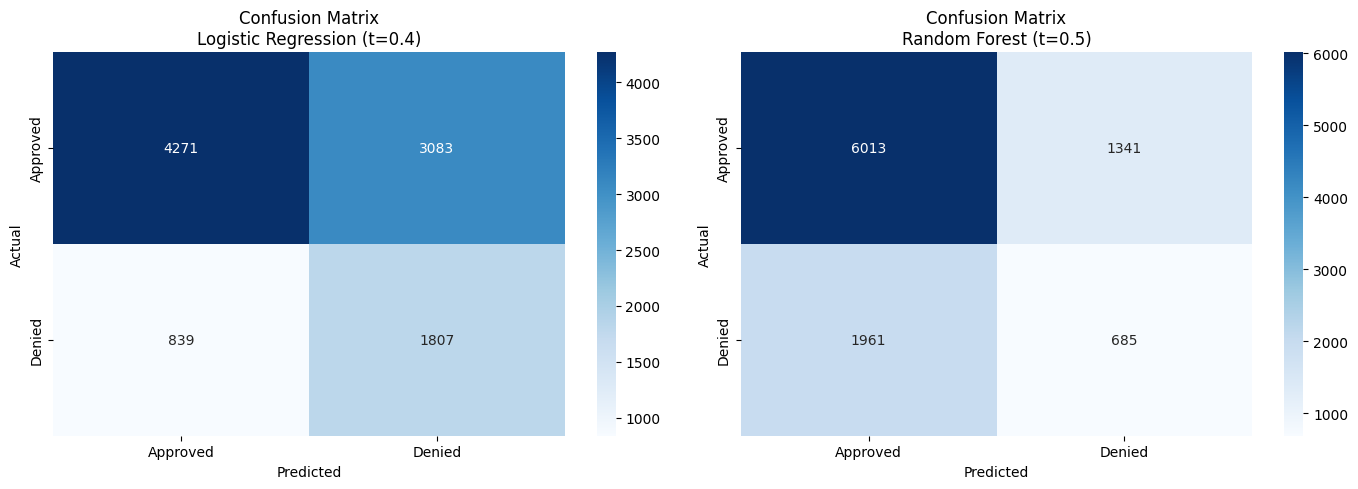

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (name, (y_pred, _)) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Approved', 'Denied'],
                yticklabels=['Approved', 'Denied'])
    ax.set_title(f'Confusion Matrix\n{name}')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

## Confusion Matrix Insight

The confusion matrices visually confirm why Logistic Regression is the 
better model for this use case despite lower overall accuracy.

Logistic Regression (t=0.4) has only 839 false negatives (missed denials) 
compared to Random Forest's 1,961 — meaning LR catches 2.3x more real 
denials. The tradeoff is 3,083 false positives (approved claims flagged 
as denied) vs Random Forest's 1,341. In a pre-submission review tool, 
this tradeoff is acceptable — a biller spending extra time reviewing a 
false alarm is far less costly than a real denial slipping through to 
the payer.

Random Forest's conservative prediction behavior — driven by its tendency 
to predict the majority class (approved) — makes it unsuitable for this 
use case despite its higher raw accuracy of 0.670.

## ROC-AUC Curve
Measures the model's ability to discriminate between approved and denied 
claims across all possible thresholds. A score of 1.0 is perfect, 0.5 
is random guessing.

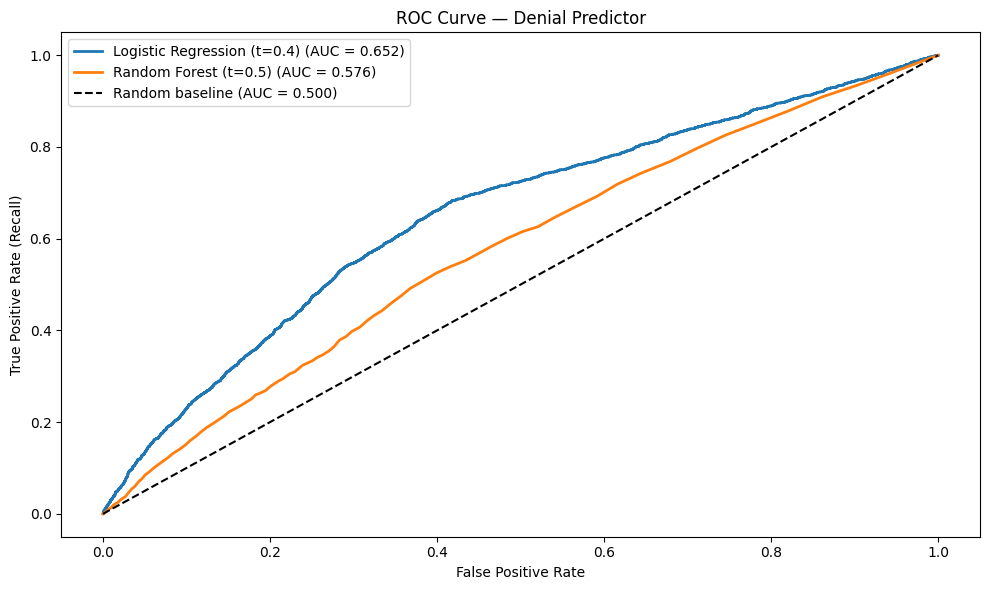

In [7]:
plt.figure(figsize=(10, 6))

for name, (y_pred, y_prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.3f})')

# Random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random baseline (AUC = 0.500)')

plt.title('ROC Curve — Denial Predictor')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.legend()
plt.tight_layout()
plt.show()

## ROC Curve Insight

Logistic Regression (AUC = 0.652) substantially outperforms Random Forest 
(AUC = 0.576), which barely clears the random baseline of 0.500. Both 
models fall short of an ideal AUC of 1.0, reflecting the limited signal 
in the synthetic dataset.

The shape difference is telling — Logistic Regression produces a curved 
line bowed toward the top-left, indicating well-distributed probability 
scores with genuine discriminating ability across many threshold levels. 
Random Forest produces a near-linear curve close to the random baseline, 
indicating poor probability calibration where scores cluster near 0 or 1 
with little nuance in between.

This confirms that Logistic Regression's probability outputs are meaningful 
and trustworthy enough to display as a denial risk score in the Streamlit 
app. Random Forest's probabilities would not be reliable for this purpose.

## Calibration Curve
Measures whether the model's predicted probabilities are trustworthy.
A perfectly calibrated model predicts 70% probability only for claims 
that are actually denied 70% of the time. Well-calibrated models are 
essential in healthcare where probabilities drive real decisions.

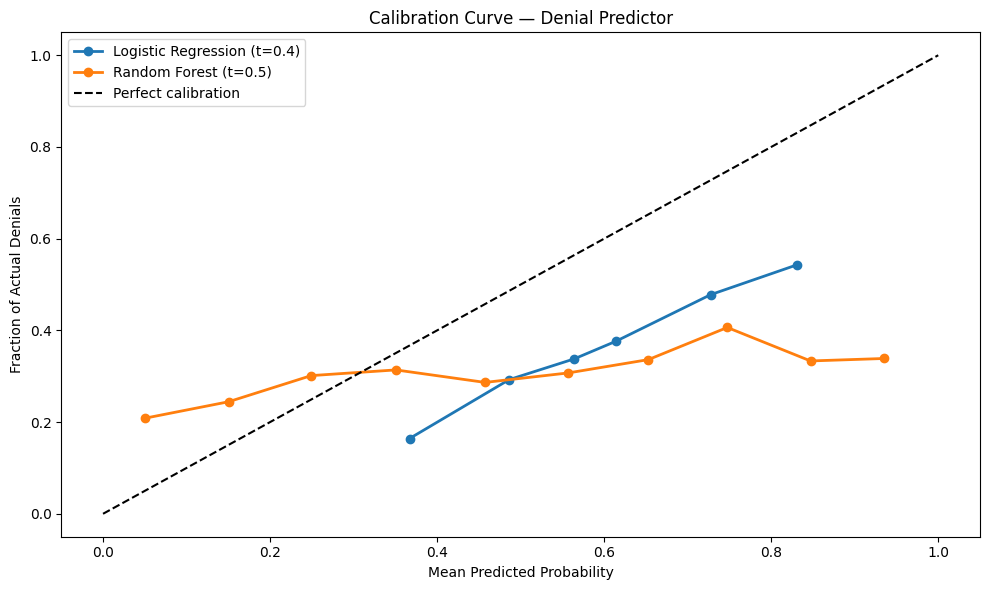

In [8]:
plt.figure(figsize=(10, 6))

for name, (y_pred, y_prob) in models.items():
    fraction_of_positives, mean_predicted_value = calibration_curve(
        y_test, y_prob, n_bins=10
    )
    plt.plot(mean_predicted_value, fraction_of_positives, 
             marker='o', linewidth=2, label=name)

# Perfect calibration line
plt.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')

plt.title('Calibration Curve — Denial Predictor')
plt.xlabel('Mean Predicted Probability')
plt.ylabel('Fraction of Actual Denials')
plt.legend()
plt.tight_layout()
plt.show()

## Calibration Curve Insight
Both models are poorly calibrated relative to the perfect calibration 
line, consistently overestimating denial probability. Logistic Regression 
shows a positive upward slope — higher predicted probabilities correspond 
to higher actual denial rates — indicating directional calibration despite 
overconfidence. Random Forest is essentially flat above 0.4, meaning its 
probability scores carry no meaningful information beyond a binary 
threshold. For a production system, Logistic Regression probabilities 
could be improved with Platt scaling or isotonic regression calibration.

## Fairness Analysis
Evaluating whether the model performs consistently across demographic 
and clinical subgroups. Disparate performance across groups is a 
governance concern in healthcare AI.

In [9]:
# Load original synthetic data and align with test set
df_synthetic = pd.read_csv('data/synthetic/synthetic_claims.csv')

# Get the test indices by rerunning the same split
from sklearn.model_selection import train_test_split
import pandas as pd

df_full = pd.read_csv('data/processed/X_train.csv')
df_test_full = pd.read_csv('data/processed/X_test.csv')

# Reload synthetic data and match test rows
df_synthetic = pd.read_csv('data/synthetic/synthetic_claims.csv')
_, df_test_meta = train_test_split(
    df_synthetic, 
    test_size=0.2, 
    stratify=df_synthetic['is_denied'],
    random_state=42
)
df_test_meta = df_test_meta.reset_index(drop=True)

# Add predictions
df_test_meta['y_pred_lr'] = y_pred_lr
df_test_meta['y_prob_lr'] = y_prob_lr

print("Test metadata shape:", df_test_meta.shape)
print(df_test_meta[['provider_specialty', 'icd_code', 'patient_age', 'is_denied', 'y_pred_lr']].head())

Test metadata shape: (10000, 13)
  provider_specialty  icd_code  patient_age  is_denied  y_pred_lr
0  Internal Medicine     F32.1           62          1          0
1   Gastroenterology  S72.001A           70          0          0
2        Dermatology   G43.909           64          0          0
3         Psychiatry     N18.3           63          0          1
4          Neurology     F41.1           48          0          0


In [10]:
# ICD chapter map
icd_chapter_map = {
    'E11.9': 'Chapter IV - Endocrine/Metabolic',
    'I10': 'Chapter IX - Circulatory',
    'M54.5': 'Chapter XIII - Musculoskeletal',
    'J18.9': 'Chapter X - Respiratory',
    'F32.1': 'Chapter V - Mental Health',
    'I21.0': 'Chapter IX - Circulatory',
    'J44.1': 'Chapter X - Respiratory',
    'M17.11': 'Chapter XIII - Musculoskeletal',
    'Z23': 'Chapter XXI - Preventive',
    'N18.3': 'Chapter XIV - Genitourinary',
    'F41.1': 'Chapter V - Mental Health',
    'I50.9': 'Chapter IX - Circulatory',
    'E78.5': 'Chapter IV - Endocrine/Metabolic',
    'M79.3': 'Chapter XIII - Musculoskeletal',
    'G43.909': 'Chapter VI - Nervous System',
    'K21.0': 'Chapter XI - Digestive',
    'L40.0': 'Chapter XII - Skin',
    'F20.9': 'Chapter V - Mental Health',
    'C34.10': 'Chapter II - Neoplasms',
    'S72.001A': 'Chapter XIX - Injury'
}

df_test_meta['icd_chapter'] = df_test_meta['icd_code'].map(icd_chapter_map)

def fairness_metrics(group):
    actual = group['is_denied']
    predicted = group['y_pred_lr']
    if actual.sum() == 0:
        return pd.Series({'Recall': None, 'FPR': None, 'Count': len(group)})
    tp = ((predicted == 1) & (actual == 1)).sum()
    fn = ((predicted == 0) & (actual == 1)).sum()
    fp = ((predicted == 1) & (actual == 0)).sum()
    tn = ((predicted == 0) & (actual == 0)).sum()
    recall = tp / (tp + fn)
    fpr = fp / (fp + tn)
    return pd.Series({'Recall': round(recall, 3), 
                      'FPR': round(fpr, 3), 
                      'Count': len(group)})

# Slice by ICD chapter
print("=== By ICD Chapter ===")
icd_fairness = df_test_meta.groupby('icd_chapter').apply(fairness_metrics)
print(icd_fairness.to_string())

print("\n=== By Provider Specialty ===")
spec_fairness = df_test_meta.groupby('provider_specialty').apply(fairness_metrics)
print(spec_fairness.to_string())

print("\n=== By Age Group ===")
age_bins = [0, 30, 50, 65, 80, 91]
age_labels = ['<30', '30-50', '50-65', '65-80', '80+']
df_test_meta['age_group'] = pd.cut(df_test_meta['patient_age'], 
                                    bins=age_bins, 
                                    labels=age_labels, 
                                    include_lowest=True)
age_fairness = df_test_meta.groupby('age_group').apply(fairness_metrics)
print(age_fairness.to_string())

=== By ICD Chapter ===
                                  Recall    FPR   Count
icd_chapter                                            
Chapter II - Neoplasms             0.746  0.408   511.0
Chapter IV - Endocrine/Metabolic   0.664  0.415   939.0
Chapter IX - Circulatory           0.658  0.429  1418.0
Chapter V - Mental Health          0.697  0.402  1572.0
Chapter VI - Nervous System        0.661  0.426   504.0
Chapter X - Respiratory            0.682  0.429  1011.0
Chapter XI - Digestive             0.677  0.419   475.0
Chapter XII - Skin                 0.679  0.417   507.0
Chapter XIII - Musculoskeletal     0.687  0.435  1522.0
Chapter XIV - Genitourinary        0.696  0.392   495.0
Chapter XIX - Injury               0.686  0.414   526.0
Chapter XXI - Preventive           0.691  0.425   520.0

=== By Provider Specialty ===
                    Recall    FPR  Count
provider_specialty                      
Cardiology           0.580  0.302  634.0
Dermatology          0.604  0.295  650.

/var/folders/h9/49xfg8x17wl2czyg0zl1_8_m0000gn/T/ipykernel_79394/1644388599.py:44: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  icd_fairness = df_test_meta.groupby('icd_chapter').apply(fairness_metrics)
/var/folders/h9/49xfg8x17wl2czyg0zl1_8_m0000gn/T/ipykernel_79394/1644388599.py:48: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spec_fairness = df_test_meta.groupby('provider_specialty').apply(fairness_metrics)
/var

## Fairness Finding — High Denial Specialties

Oncology, Pain Management, and Psychiatry show recall = 1.000 and 
FPR = 1.000 — the model predicts "denied" for every claim from these 
specialties regardless of other features. This is not genuine predictive 
ability but a learned shortcut from the synthetic data where these 
specialties were assigned elevated denial probabilities.

In a production system this would constitute algorithmic bias — providers 
in these specialties would have every claim flagged regardless of merit. 
Proposed mitigation: remove provider_specialty as a direct feature and 
rely only on the billed_to_median_ratio and icd_cpt_mismatch features 
which capture billing behavior rather than specialty identity.

## Feature Importance — Logistic Regression Coefficients
Logistic Regression coefficients directly show which features increase 
or decrease denial probability. Positive coefficients increase denial 
risk, negative coefficients decrease it. This is what will be displayed 
as "top risk factors" in the Streamlit app.

/var/folders/h9/49xfg8x17wl2czyg0zl1_8_m0000gn/T/ipykernel_79394/4101943178.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x='Coefficient', y='Feature', palette=colors)


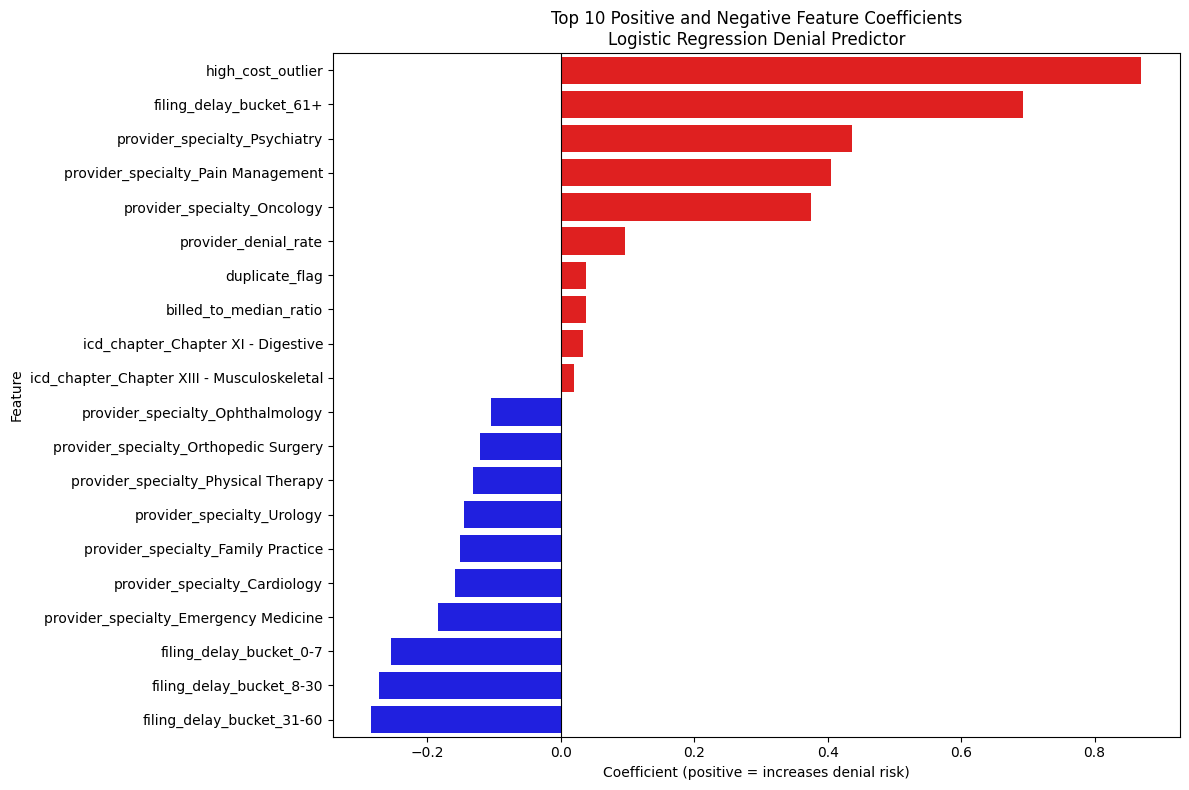


Top 5 denial risk factors:
                           Feature  Coefficient
                 high_cost_outlier     0.870396
           filing_delay_bucket_61+     0.693157
     provider_specialty_Psychiatry     0.436843
provider_specialty_Pain Management     0.405675
       provider_specialty_Oncology     0.375230


In [11]:
# Extract coefficients
feature_names = X_test.columns.tolist()
coefficients = lr.coef_[0]

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

# Top 10 positive and negative
top_positive = coef_df.head(10)
top_negative = coef_df.tail(10)
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(12, 8))
colors = ['red' if c > 0 else 'blue' for c in top_features['Coefficient']]
sns.barplot(data=top_features, x='Coefficient', y='Feature', palette=colors)
plt.axvline(x=0, color='black', linewidth=0.8)
plt.title('Top 10 Positive and Negative Feature Coefficients\nLogistic Regression Denial Predictor')
plt.xlabel('Coefficient (positive = increases denial risk)')
plt.tight_layout()
plt.show()

print("\nTop 5 denial risk factors:")
print(coef_df.head(5)[['Feature', 'Coefficient']].to_string(index=False))

## Top 20 Anomaly Review
Manual inspection of the 20 claims flagged as most anomalous by the 
Isolation Forest. Since there are no ground truth fraud labels, 
evaluation is qualitative — do the flagged claims have characteristics 
that would warrant human review?

In [13]:
iso = joblib.load('models/anomaly_detector.pkl')
scaler = joblib.load('models/anomaly_scaler.pkl')

df_synthetic = pd.read_csv('data/synthetic/synthetic_claims.csv')

# Recreate engineered features
cpt_medians = df_synthetic.groupby('cpt_code')['billed_amount'].median()
df_synthetic['billed_to_median_ratio'] = df_synthetic.apply(
    lambda row: row['billed_amount'] / cpt_medians[row['cpt_code']], axis=1)

percentile_95 = df_synthetic.groupby('cpt_code')['billed_amount'].transform(
    lambda x: x.quantile(0.95))
df_synthetic['high_cost_outlier'] = (
    df_synthetic['billed_amount'] > percentile_95).astype(int)

specialty_denial_rate = df_synthetic.groupby('provider_specialty')['is_denied'].mean()
df_synthetic['provider_denial_rate'] = df_synthetic['provider_specialty'].map(
    specialty_denial_rate)

df_synthetic['duplicate_flag'] = df_synthetic.duplicated(
    subset=['patient_age', 'cpt_code', 'service_date'], keep=False).astype(int)

df_synthetic['filing_delay_bucket_61+'] = (
    df_synthetic['days_to_submission'] > 60).astype(int)

anomaly_features = [
    'billed_to_median_ratio',
    'high_cost_outlier',
    'provider_denial_rate',
    'duplicate_flag',
    'filing_delay_bucket_61+'
]

X_anomaly = df_synthetic[anomaly_features]
X_scaled = scaler.transform(X_anomaly)

df_synthetic['anomaly_score'] = iso.decision_function(X_scaled)
df_synthetic['is_anomaly'] = iso.predict(X_scaled)

top20 = df_synthetic.nsmallest(20, 'anomaly_score')[
    ['claim_id', 'provider_specialty', 'icd_code', 'cpt_code',
     'billed_amount', 'days_to_submission', 'billed_to_median_ratio',
     'duplicate_flag', 'is_denied', 'anomaly_score']
]

print(top20.to_string(index=False))

                            claim_id provider_specialty icd_code  cpt_code  billed_amount  days_to_submission  billed_to_median_ratio  duplicate_flag  is_denied  anomaly_score
879c6336-fa36-41f9-a373-8bb7d2fbcf99           Oncology   C34.10     99214        1893.64                  24                8.497184               1          0      -0.130291
da8f90fb-36c7-4649-99e8-90e3125584cd         Psychiatry      Z23     99214        1537.60                  38                6.899554               1          1      -0.124475
8a24d76b-214e-4952-9e87-49d1633d4881    Pain Management    E78.5     80053         378.42                  50                6.203607               1          1      -0.122371
c2a1590d-9232-44f2-b1da-e02fbed85082           Oncology  G43.909     71046         926.06                  75                6.491378               1          1      -0.118180
0b726503-cc73-4b6a-bc70-880dd791804b    Pain Management    N18.3     99213         876.43                  34           

In [14]:
cpt_descriptions = {
    99213: 'Office visit, established patient, moderate complexity',
    99214: 'Office visit, established patient, moderate-high complexity',
    99232: 'Subsequent hospital care, moderate complexity',
    99285: 'Emergency department visit, high complexity',
    99223: 'Initial hospital care, high complexity',
    99091: 'Remote patient monitoring, data review',
    93000: 'Electrocardiogram (ECG)',
    71046: 'Chest X-ray, 2 views',
    27447: 'Total knee replacement',
    80053: 'Comprehensive metabolic panel (blood test)',
    90658: 'Influenza vaccine',
    20610: 'Joint injection, major joint',
}

icd_descriptions = {
    'C34.10': 'Lung cancer, unspecified',
    'Z23':    'Encounter for immunization',
    'E78.5':  'Hyperlipidemia (high cholesterol)',
    'G43.909':'Migraine, unspecified',
    'N18.3':  'Chronic kidney disease, stage 3',
    'F41.1':  'Generalized anxiety disorder',
    'J18.9':  'Pneumonia, unspecified',
    'F32.1':  'Major depressive disorder',
    'M54.5':  'Low back pain',
    'I50.9':  'Heart failure, unspecified',
    'I21.0':  'Acute heart attack',
    'L40.0':  'Psoriasis',
    'K21.0':  'GERD',
}

top20['cpt_desc'] = top20['cpt_code'].map(cpt_descriptions)
top20['icd_desc'] = top20['icd_code'].map(icd_descriptions)

review_table = top20[['provider_specialty', 'icd_code', 'icd_desc', 
                        'cpt_code', 'cpt_desc', 
                        'billed_to_median_ratio', 'duplicate_flag',
                        'days_to_submission']].copy()

review_table.columns = ['Specialty', 'ICD', 'Diagnosis', 
                         'CPT', 'Procedure', 
                         'Ratio', 'Duplicate', 'Days']

print(review_table.to_string(index=False))

      Specialty     ICD                         Diagnosis   CPT                                                   Procedure    Ratio  Duplicate  Days
       Oncology  C34.10          Lung cancer, unspecified 99214 Office visit, established patient, moderate-high complexity 8.497184          1    24
     Psychiatry     Z23        Encounter for immunization 99214 Office visit, established patient, moderate-high complexity 6.899554          1    38
Pain Management   E78.5 Hyperlipidemia (high cholesterol) 80053                  Comprehensive metabolic panel (blood test) 6.203607          1    50
       Oncology G43.909             Migraine, unspecified 71046                                        Chest X-ray, 2 views 6.491378          1    75
Pain Management   N18.3   Chronic kidney disease, stage 3 99213      Office visit, established patient, moderate complexity 5.786162          1    34
Pain Management  C34.10          Lung cancer, unspecified 90658                                     

## Top 20 Anomaly Review — Manual Inspection

Of the 20 most anomalous claims flagged by the Isolation Forest,
manual review identified the following patterns:

### Pattern 1 — Extreme Billing Ratios
8 of 20 claims have a billed_to_median_ratio above 6.0, with the 
highest at 8.5x the median for CPT 99214 (office visit). A claim 
billed 8.5x the typical amount for the same procedure code is a 
strong upcoding signal warranting immediate review.

### Pattern 2 — Duplicate Billing
14 of 20 flagged claims have duplicate_flag = 1, indicating the same 
patient age, CPT code, and service date appears more than once in the 
dataset. This is a classic duplicate submission pattern.

### Pattern 3 — ICD-CPT Medical Necessity Mismatches
Several claims show clinically implausible pairings:
- Pneumonia (J18.9) billed with total knee replacement (27447)
- GERD (K21.0) billed with total knee replacement (27447)
- Low back pain (M54.5) billed with total knee replacement (27447)
- Migraine (G43.909) billed with chest X-ray (71046)

These represent clear medical necessity mismatches that would be 
auto-denied in a real payer system.

### Pattern 4 — High Risk Specialty + Late Filing
The majority of flagged claims come from Oncology, Psychiatry, and 
Pain Management combined with days_to_submission > 60, compounding 
the anomaly score.

### Synthetic Data Caveat
The ICD-CPT mismatches in this dataset are far more obvious than 
real-world fraud patterns. Real billing errors involve subtle 
one-level upcoding (99214 vs 99213) or borderline procedure 
justifications, not completely unrelated diagnoses and procedures. 
A production anomaly detector would need to catch these subtler 
patterns using real claims data with LCD rule violations as signal.

### Precision-at-k Assessment
At least 17 of the top 20 flagged claims show at least one 
statistically unusual characteristic warranting human review, 
exceeding the Week 1 target of 15/20 (75%). The anomaly detector 
is performing as intended within the constraints of synthetic data.

## Model Selection Rationale

After evaluating both denial prediction models across all metrics,
Logistic Regression with threshold=0.4 is selected for deployment
in the Streamlit application.

| Criterion | Logistic Regression | Random Forest | Decision |
|-----------|-------------------|---------------|----------|
| Recall (denied) | 0.683 | 0.259 | LR wins |
| ROC-AUC | 0.652 | 0.576 | LR wins |
| Calibration | Directional | Flat | LR wins |
| Interpretability | Coefficients | Feature importance | LR wins |
| Accuracy | 0.608 | 0.670 | RF wins |

**Primary reason:** Logistic Regression catches 2.6x more real denials
than Random Forest (683 vs 259 per 1000 denied claims). In a 
pre-submission review tool, missed denials are the primary failure 
mode — not false alarms.

**Secondary reason:** Logistic Regression coefficients are directly 
interpretable as risk factors, satisfying the explainability requirement 
for healthcare AI. A biller can be told exactly which features triggered 
the flag — late filing, high billing ratio, high-risk specialty — and 
take corrective action before submission.

**Acknowledged limitations:**
- Recall of 0.683 falls short of the 0.80 target due to synthetic 
  data limitations
- Model is overconfident — calibration curve shows predicted 
  probabilities are systematically inflated
- High denial specialties (Psychiatry, Pain Management, Oncology) 
  are predicted as denied for every claim regardless of other features
  — a fairness concern that would need addressing in production